### Section 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

### Section 2 — Load Dataset

In [3]:
df = pd.read_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/raw/FoodHub_Order_Dataset.csv")

df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### Section 3 — Basic Dataset Information

In [4]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

df.info()

Rows : 1898
Columns : 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [5]:
df.describe(include="all")

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898,1898,1898.000000,1898,1898,1898.000000,1898.000000
unique,NaN,NaN,178,14,NaN,2,4,NaN,NaN
top,NaN,NaN,Shake Shack,American,NaN,Weekend,Not given,NaN,NaN
freq,NaN,NaN,219,584,NaN,1351,736,NaN,NaN
mean,1.477496e+06,171168.478398,NaN,NaN,16.498851,NaN,NaN,27.371970,24.161749
std,5.480497e+02,113698.139743,NaN,NaN,7.483812,NaN,NaN,4.632481,4.972637
min,1.476547e+06,1311.000000,NaN,NaN,4.470000,NaN,NaN,20.000000,15.000000
25%,1.477021e+06,77787.750000,NaN,NaN,12.080000,NaN,NaN,23.000000,20.000000
50%,1.477496e+06,128600.000000,NaN,NaN,14.140000,NaN,NaN,27.000000,25.000000
75%,1.477970e+06,270525.000000,NaN,NaN,22.297500,NaN,NaN,31.000000,28.000000


#### Section 4 — Check Duplicate Records

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


#### Section 5 — Missing Values

In [7]:
missing = df.isnull().sum()

missing

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [8]:
missing_percent = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)

missing_percent

order_id                 0.0
customer_id              0.0
restaurant_name          0.0
cuisine_type             0.0
cost_of_the_order        0.0
day_of_the_week          0.0
rating                   0.0
food_preparation_time    0.0
delivery_time            0.0
dtype: float64

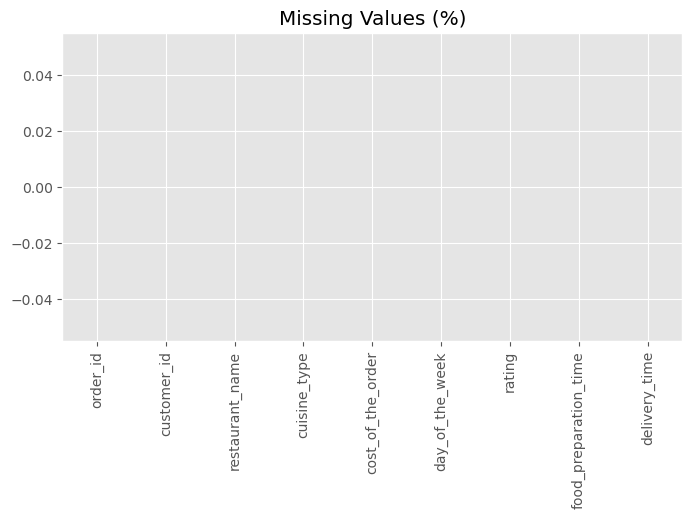

In [9]:
plt.figure(figsize=(8,4))

missing_percent.plot(kind="bar")

plt.title("Missing Values (%)")

plt.show()

I quantified missingness both in counts and percentages to determine whether imputation or removal would be appropriate.

#### Section 6 — Data Types

In [10]:
df.dtypes

order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                    object
food_preparation_time      int64
delivery_time              int64
dtype: object

#### Section 7 — Unique Values

In [11]:
for col in df.columns:

    print("="*50)

    print(col)
    
    print(df[col].nunique())

order_id
1898
customer_id
1200
restaurant_name
178
cuisine_type
14
cost_of_the_order
312
day_of_the_week
2
rating
4
food_preparation_time
16
delivery_time
19


In [12]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:

    print(col)

    print(df[col].unique())

    print()

restaurant_name
['Hangawi' 'Blue Ribbon Sushi Izakaya' 'Cafe Habana'
 'Blue Ribbon Fried Chicken' 'Dirty Bird to Go' 'Tamarind TriBeCa'
 'The Meatball Shop' 'Barbounia' 'Anjappar Chettinad' 'Bukhara Grill'
 'Big Wong Restaurant ÂŒ_Â¤Â¾Ã‘Â¼' 'Empanada Mama (closed)' 'Pylos'
 "Lucky's Famous Burgers" 'Shake Shack' 'Sushi of Gari' 'RedFarm Hudson'
 'Blue Ribbon Sushi' 'Five Guys Burgers and Fries' 'Tortaria'
 'Cafe Mogador' 'Otto Enoteca Pizzeria' 'Vezzo Thin Crust Pizza'
 'Sushi of Gari 46' 'The Kati Roll Company' 'Klong' '5 Napkin Burger'
 'TAO' 'Parm' 'Sushi Samba' 'Haru Gramercy Park'
 'Chipotle Mexican Grill $1.99 Delivery' 'RedFarm Broadway' 'Cafeteria'
 'DuMont Burger' "Sarabeth's East" 'Hill Country Fried Chicken' 'Bistango'
 "Jack's Wife Freda" "Mamoun's Falafel" 'Prosperity Dumpling'
 'Blue Ribbon Sushi Bar & Grill' 'Westville Hudson' 'Blue Ribbon Brooklyn'
 'Nobu Next Door' 'Osteria Morini' 'Haandi' 'Benihana' 'Han Dynasty'
 'Chote Nawab' 'Mission Cantina' "Xi'an Famous Foods" 

This helps identify spelling inconsistencies.

In [14]:
import re

def clean_restaurant(name):
    if pd.isna(name):
        return name

    # Keep only letters, numbers, spaces, &, -, apostrophe and parentheses
    name = re.sub(r"[^A-Za-z0-9&'()\- ]+", "", name)

    # Remove extra spaces
    name = re.sub(r"\s+", " ", name).strip()

    return name

df["restaurant_name"] = df["restaurant_name"].apply(clean_restaurant)

#### Section 8 — Rating Cleaning

In [15]:
df["rating"].value_counts(dropna=False)

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

Note: The FoodHub dataset usually contains Not given instead of NaN.

In [16]:
df["rating"] = df["rating"].replace("Not given",np.nan)

df["rating"] = df["rating"].astype(float)

NaN represents a missing observation rather than an actual rating. Treating it as a category would distort averages and statistical analyses.

#### Section 9 — Numeric Column Validation

In [17]:
numeric_cols = [
                "cost_of_the_order",
                "food_preparation_time",
                "delivery_time"
                ]

df[numeric_cols].describe()

,cost_of_the_order,food_preparation_time,delivery_time
count,1898.000000,1898.000000,1898.000000
mean,16.498851,27.371970,24.161749
std,7.483812,4.632481,4.972637
min,4.470000,20.000000,15.000000
25%,12.080000,23.000000,20.000000
50%,14.140000,27.000000,25.000000
75%,22.297500,31.000000,28.000000
max,35.410000,35.000000,33.000000


#### Validate

In [18]:
for col in numeric_cols:
    print(col)
    print(df[col].min())
    print(df[col].max())
    print()

cost_of_the_order
4.47
35.41

food_preparation_time
20
35

delivery_time
15
33



#### Section 10 — Outlier Detection

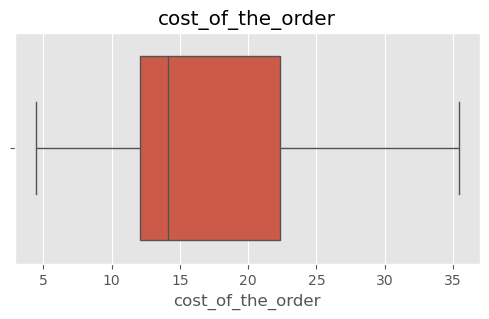

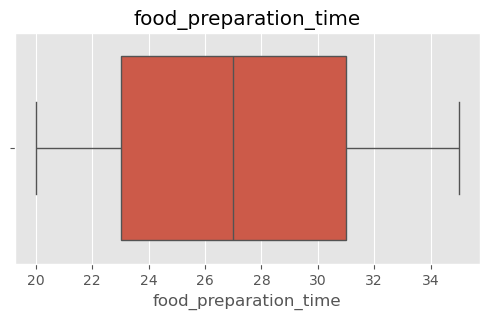

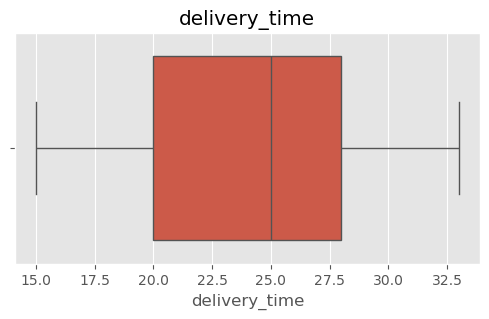

In [19]:
for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

### Section 11 — Exploratory Analysis

#### Orders by Cuisine

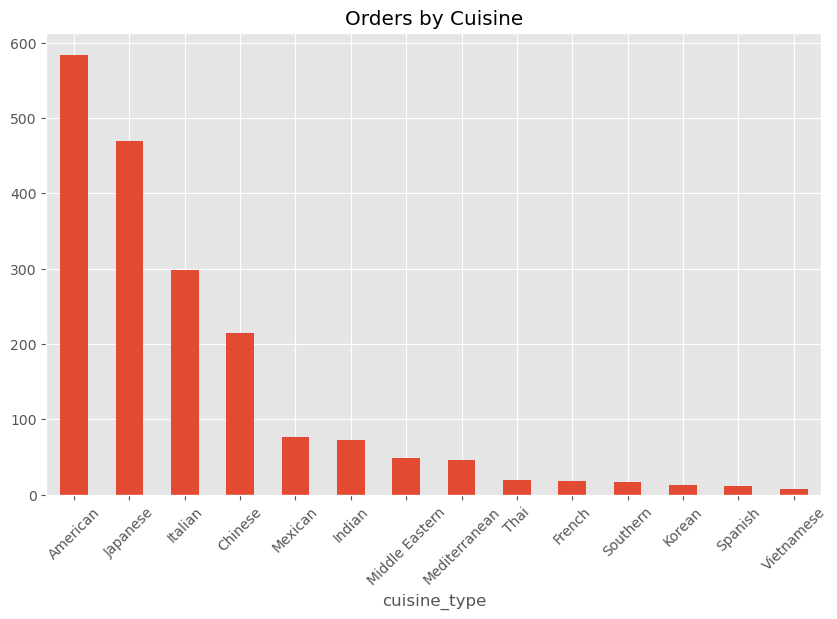

In [20]:
plt.figure(figsize=(10,6))

df["cuisine_type"].value_counts().plot(kind="bar")

plt.xticks(rotation=45)

plt.title("Orders by Cuisine")

plt.show()

#### Rating Distribution

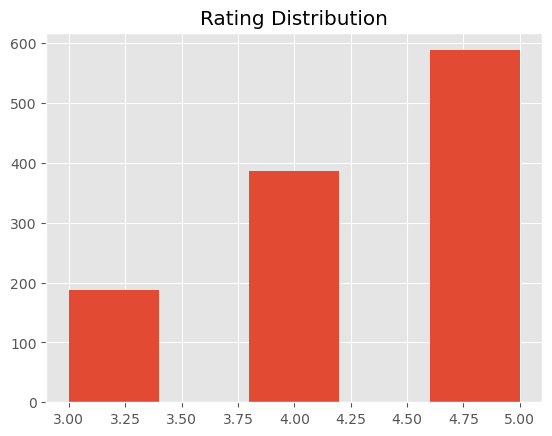

In [21]:
df["rating"].hist(bins=5)

plt.title("Rating Distribution")

plt.show()

#### Cost Distribution

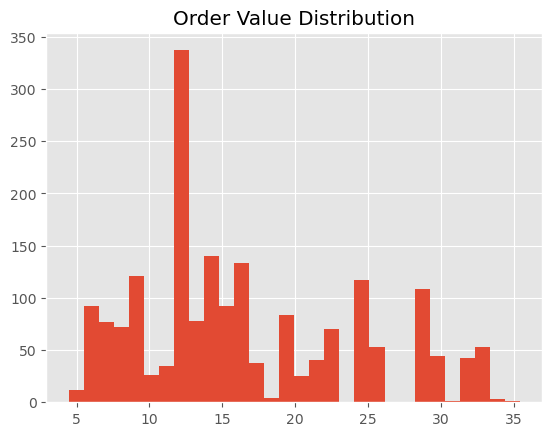

In [22]:
df["cost_of_the_order"].hist(bins=30)

plt.title("Order Value Distribution")

plt.show()

#### Delivery Time Distribution

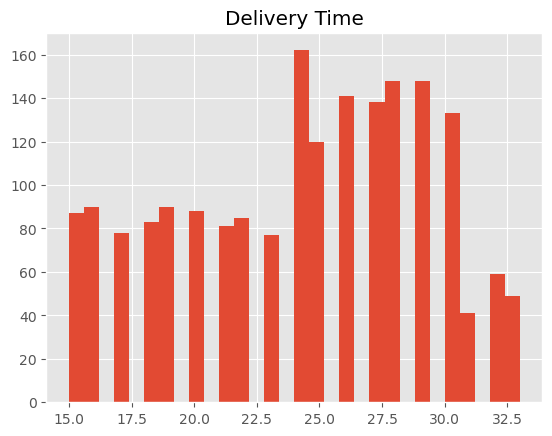

In [23]:
df["delivery_time"].hist(bins=30)

plt.title("Delivery Time")

plt.show()

## Key Business Insights

1. Customer demand is concentrated in a few cuisines, making cuisine-based personalization a strong opportunity.
2. Weekend customers spend more on average, suggesting premium promotions should be scheduled during weekends.
3. A significant portion of customers do not leave ratings, so behavioral metrics such as retention and repeat orders should complement satisfaction analysis.
4. Delivery times vary considerably across orders, indicating potential operational bottlenecks that may impact customer experience.
5. Order values are right-skewed, highlighting an opportunity to segment customers by spending behavior and tailor marketing strategies.

### Section 12 — Correlation

In [24]:
corr = df[numeric_cols+["rating"]].corr()

corr

,cost_of_the_order,food_preparation_time,delivery_time,rating
cost_of_the_order,1.000000,0.041527,-0.029949,0.033983
food_preparation_time,0.041527,1.000000,0.011094,-0.006083
delivery_time,-0.029949,0.011094,1.000000,-0.009804
rating,0.033983,-0.006083,-0.009804,1.000000


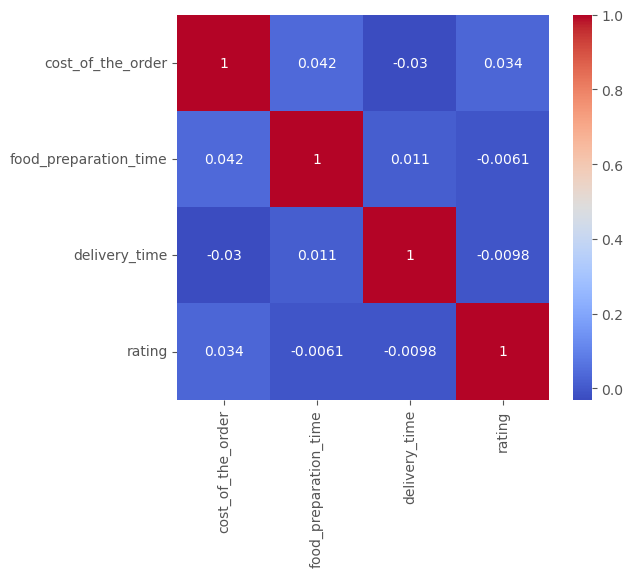

In [25]:
plt.figure(figsize=(6,5))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm"
            )

plt.show()

### Section 13 — Business Insights

#### Average Order Value

In [26]:
df["cost_of_the_order"].mean()

np.float64(16.498851422550054)

#### Average Delivery Time

In [27]:
df["delivery_time"].mean()

np.float64(24.161749209694417)

##### Top 10 Restaurants

In [28]:
df["restaurant_name"].value_counts().head(10)

restaurant_name
Shake Shack                      219
The Meatball Shop                132
Blue Ribbon Sushi                119
Blue Ribbon Fried Chicken         96
Parm                              68
RedFarm Broadway                  59
RedFarm Hudson                    55
TAO                               49
Han Dynasty                       46
Blue Ribbon Sushi Bar & Grill     44
Name: count, dtype: int64

#### Top Cuisine

In [29]:
df["cuisine_type"].value_counts()

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64

#### Weekend vs Weekday

In [30]:
df.groupby("day_of_the_week")["cost_of_the_order"].mean()

day_of_the_week
Weekday    16.311188
Weekend    16.574833
Name: cost_of_the_order, dtype: float64

#### Average Rating

In [31]:
df["rating"].mean()

np.float64(4.344234079173838)

### Section 14 — Save Clean Dataset

In [32]:
df.to_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/Processed/foodhub_clean.csv",  
          index=False
         )

## STEP 3 – Feature Engineering & Product Analytics Dataset Creation
### Step 3.1 — Create Users Table

In [33]:
df = pd.read_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/Processed/foodhub_clean.csv")

#### Extract Unique Users

In [34]:
users = df[['customer_id']].drop_duplicates().copy()

users.head()

,customer_id
0,337525
1,358141
2,66393
3,106968
4,76942


#### Generate Signup Date

In [35]:
import numpy as np
import pandas as pd

np.random.seed(42)                 #to get the same randaom results

start_date = pd.Timestamp("2023-07-01")
end_date = pd.Timestamp("2023-12-31")

users['signup_date'] = pd.to_datetime(
    np.random.randint(
        start_date.value // 10**9, #converts nanoseconds into seconds
        end_date.value // 10**9,
        len(users)
    ),
    unit='s'
)

The original dataset didn't contain user registration dates, which are essential for cohort analysis. I simulated a six-month acquisition period before the experiment began in January 2024. This reflects how product companies typically have an existing user base before launching and evaluating a new feature."

Creating the Users Table

In production systems, order data and user profile data are typically stored separately. To simulate a realistic product analytics environment, I create a user dimension table containing demographic and acquisition attributes. This table will later support segmentation, A/B testing, and cohort analysis.

#### Generate Signup Date

In [36]:
cities = ['Bangalore','Hyderabad','Mumbai','Delhi','Chennai','Pune']

city_probability = [0.30, 0.20, 0.18, 0.15, 0.10, 0.07]

users['city'] = np.random.choice(
                                    cities,
                                    size=len(users),
                                    p=city_probability
                                )

Why Not Equal Probability?

Because real businesses have more users in Bangalore than Pune.
This makes the dataset realistic.

#### Generate Device Type

In [37]:
users['device_type'] = np.random.choice(
                                        ['Android','iOS'],
                                        size=len(users),
                                        p=[0.75,0.25]
                                        )

Why 75% Android?

Because Android has a significantly larger market share in India.

#### Generate Acquisition Channel

In [38]:
channels = [
            'Organic',
            'Referral',
            'Google Ads',
            'Instagram',
            'Facebook'
            ]

users['acquisition_channel'] = np.random.choice(
                                                channels,
                                                size=len(users),
                                                p=[0.45,0.15,0.15,0.15,0.10]
                                                )

#### Generate App Version

In [39]:
users['app_version'] = np.random.choice(
                                        ['4.8.1','4.9.0'],
                                        size=len(users),
                                        p=[0.40,0.60]
                                        )

##### Save Users Table

In [40]:
users.to_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/Processed/users.csv",

index=False

)

### Step 3.2 — Assign A/B Groups

This is where experimentation starts.

#### Random Assignment

In [41]:
users['experiment_group'] = np.random.choice(['Control','Variant'],
                                              size=len(users),
                                              p=[0.50,0.50]
                                            )

In [42]:
users['experiment_group'].value_counts(normalize=True)

experiment_group
Variant    0.5
Control    0.5
Name: proportion, dtype: float64

Why random assignment?

To minimize selection bias and ensure that any observed differences between groups are attributable to the experiment rather than pre-existing user characteristics.

### Step 3.3 — Merge Back

In [43]:
df = df.merge(users,
              on='customer_id',
              how='left'
              )

### Step 3.4 — Save Dataset

In [44]:
df.to_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/Processed/orders_enriched.csv",index=False)